# Exploratory Data Analysis: Natural Disaster Severity Prediction

This notebook performs a comprehensive exploratory data analysis on the disaster severity dataset to understand data quality, feature distributions, temporal patterns, and relationships with the target variable.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create output folder for plots
output_dir = Path('eda_plots')
output_dir.mkdir(exist_ok=True)

print("Libraries imported successfully!")
print(f"Output directory ready: {output_dir}")

Libraries imported successfully!
Output directory ready: eda_plots


## 1. Load and Inspect the Data

Load the training dataset and examine its basic structure, dimensions, data types, and temporal coverage.

In [29]:
# Load the dataset
df = pd.read_csv('data-mining-2026-final-project/data/train.csv')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Note: The CSV has corrupted dates (years ranging 1000-8133)
# Since we have exactly 5,480 observations per region x 2,248 regions,
# we'll generate sequential daily dates instead
print("\n⚠ Note: Raw 'date' column has corrupted year values (1000-8133 range)")
print("Generating sequential daily dates for analysis...")

# Sort by region_id to group observations by region
df = df.sort_values(['region_id']).reset_index(drop=True)

# Generate sequential dates (starting from 2005-01-01)
start_date = pd.Timestamp('2005-01-01')
n_rows_per_region = len(df) // df['region_id'].nunique()

# Create date column
dates_list = []
for region in sorted(df['region_id'].unique()):
    region_mask = df['region_id'] == region
    n_obs = region_mask.sum()
    dates = pd.date_range(start=start_date, periods=n_obs, freq='D')
    dates_list.extend(dates)

df['date'] = dates_list

print("\n✓ Sequential dates generated")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Number of unique regions: {df['region_id'].nunique()}")
print(f"Observations per region: {len(df) / df['region_id'].nunique():.0f}")

# Check data
print(f"\nFirst 5 rows:")
print(df[['region_id', 'date', 'prec', 'humidity', 'tmp', 'score']].head())
print(f"\nLast 5 rows:")
print(df[['region_id', 'date', 'prec', 'humidity', 'tmp', 'score']].tail())

DATASET OVERVIEW
Shape: 12319040 rows × 17 columns

⚠ Note: Raw 'date' column has corrupted year values (1000-8133 range)
Generating sequential daily dates for analysis...

✓ Sequential dates generated
Date range: 2005-01-01 00:00:00 to 2020-01-02 00:00:00
Number of unique regions: 2248
Observations per region: 5480

First 5 rows:
  region_id       date  prec  humidity    tmp  score
0        R1 2005-01-01  0.00      3.76   5.89    NaN
1        R1 2005-01-02  0.00      5.37   8.81    NaN
2        R1 2005-01-03  0.01      9.32  13.09    NaN
3        R1 2005-01-04  0.02     11.40  16.01    NaN
4        R1 2005-01-05  1.93     12.20  17.98    NaN

Last 5 rows:
         region_id       date   prec  humidity    tmp  score
12319035      R999 2019-12-29  12.51      6.29   7.82    NaN
12319036      R999 2019-12-30   1.01      7.16   9.28    NaN
12319037      R999 2019-12-31   0.00      3.22   0.29    NaN
12319038      R999 2020-01-01   0.11      4.31   3.24    NaN
12319039      R999 2020-01-02 

In [28]:
print("\n\n" + "="*70)
print("QUICK VERIFICATION - Date conversion result:")
print("="*70)
print(f"Total rows in df: {len(df)}")
print(f"Date column dtype: {df['date'].dtype}")
print(f"Non-null dates: {df['date'].notna().sum()}")
print(f"Null dates (NaT): {df['date'].isnull().sum()}")
if df['date'].notna().sum() > 0:
    print(f"Sample valid dates:")
    print(df[df['date'].notna()]['date'].head(5).tolist())
if df['date'].isnull().sum() > 0:
    print(f"\nSample null date indices: {df[df['date'].isnull()].index[:5].tolist()}")
    print(f"Raw values for those indices:")
    df_raw_check = pd.read_csv('data-mining-2026-final-project/data/train.csv', dtype={'date': str})
    print(df_raw_check.iloc[df[df['date'].isnull()].index[:5]]['date'].tolist())
print("="*70 + "\n")



QUICK VERIFICATION - Date conversion result:
Total rows in df: 12319040
Date column dtype: datetime64[us]
Non-null dates: 1079560
Null dates (NaT): 11239480
Sample valid dates:
[Timestamp('2004-12-31 00:00:00'), Timestamp('2005-01-01 00:00:00'), Timestamp('2005-01-02 00:00:00'), Timestamp('2005-01-03 00:00:00'), Timestamp('2005-01-04 00:00:00')]

Sample null date indices: [935750, 935751, 935752, 935753, 935754]
Raw values for those indices:
['11006-12-31', '11007-01-01', '11007-01-02', '11007-01-03', '11007-01-04']



In [18]:
# Diagnostic: Check what happened to the date conversion
print("\nDiagnostic - Checking date conversion:")
df_test = pd.read_csv('data-mining-2026-final-project/data/train.csv')
print(f"Raw date values (first 50):")
print(df_test['date'].head(50).tolist())

# Apply the conversion to see what happens
from datetime import datetime

def parse_and_adjust_date_verbose(date_str):
    """Parse date string (YYYY-MM-DD) and adjust year if needed"""
    try:
        # Parse the date string
        year, month, day = map(int, date_str.split('-'))
        
        # Adjust year if it's way in the future (subtract 1000)
        if year > 2500:
            year = year - 1000
        
        # Create datetime object
        result = pd.Timestamp(year=year, month=month, day=day)
        return result
    except (ValueError, TypeError, AttributeError) as e:
        return pd.NaT

# Test on first 10 rows
print("\nTesting date conversion on first 10 rows:")
for i in range(min(10, len(df_test))):
    raw_date = df_test['date'].iloc[i]
    converted = parse_and_adjust_date_verbose(raw_date)
    print(f"  {i}: '{raw_date}' -> {converted}")


Diagnostic - Checking date conversion:
Raw date values (first 50):
['3004-12-31', '3005-01-01', '3005-01-02', '3005-01-03', '3005-01-04', '3005-01-05', '3005-01-06', '3005-01-07', '3005-01-08', '3005-01-09', '3005-01-10', '3005-01-11', '3005-01-12', '3005-01-13', '3005-01-14', '3005-01-15', '3005-01-16', '3005-01-17', '3005-01-18', '3005-01-19', '3005-01-20', '3005-01-21', '3005-01-22', '3005-01-23', '3005-01-24', '3005-01-25', '3005-01-26', '3005-01-27', '3005-01-28', '3005-01-29', '3005-01-30', '3005-01-31', '3005-02-01', '3005-02-02', '3005-02-03', '3005-02-04', '3005-02-05', '3005-02-06', '3005-02-07', '3005-02-08', '3005-02-09', '3005-02-10', '3005-02-11', '3005-02-12', '3005-02-13', '3005-02-14', '3005-02-15', '3005-02-16', '3005-02-17', '3005-02-18']

Testing date conversion on first 10 rows:
  0: '3004-12-31' -> 2004-12-31 00:00:00
  1: '3005-01-01' -> 2005-01-01 00:00:00
  2: '3005-01-02' -> 2005-01-02 00:00:00
  3: '3005-01-03' -> 2005-01-03 00:00:00
  4: '3005-01-04' -> 200

In [11]:
# First, reload raw data to inspect original format
df_raw = pd.read_csv('data-mining-2026-final-project/data/train.csv')
print("RAW DATE VALUES (before conversion):")
print("Data type:", df_raw['date'].dtype)
print("\nSample raw values:")
print(df_raw['date'].head(30))

print("\nUnique raw date values (first 30):")
print(df_raw['date'].unique()[:30])

print("\nValue counts for date column (top 20):")
print(df_raw['date'].value_counts().head(20))

# Check if there are invalid entries
print("\nChecking for invalid date patterns...")
invalid_mask = pd.isna(df_raw['date'])
print(f"NaN values in raw data: {invalid_mask.sum()}")

# Try parsing with different formats
print("\n\nAttempting different date formats...")
for fmt in ['%Y-%m-%d', '%Y/%m/%d', '%d-%m-%Y', '%m-%d-%Y', 'mixed']:
    try:
        test_convert = pd.to_datetime(df_raw['date'], format=fmt, errors='coerce')
        invalid_count = test_convert.isnull().sum()
        print(f"Format '{fmt}': {invalid_count} invalid values")
        if invalid_count < 50000:
            print(f"  Sample converted values: {test_convert[test_convert.notna()].head(3).tolist()}")
    except Exception as e:
        print(f"Format '{fmt}': Error - {str(e)[:80]}")

RAW DATE VALUES (before conversion):
Data type: str

Sample raw values:
0     3004-12-31
1     3005-01-01
2     3005-01-02
3     3005-01-03
4     3005-01-04
5     3005-01-05
6     3005-01-06
7     3005-01-07
8     3005-01-08
9     3005-01-09
10    3005-01-10
11    3005-01-11
12    3005-01-12
13    3005-01-13
14    3005-01-14
15    3005-01-15
16    3005-01-16
17    3005-01-17
18    3005-01-18
19    3005-01-19
20    3005-01-20
21    3005-01-21
22    3005-01-22
23    3005-01-23
24    3005-01-24
25    3005-01-25
26    3005-01-26
27    3005-01-27
28    3005-01-28
29    3005-01-29
Name: date, dtype: str

Unique raw date values (first 30):
<ArrowStringArray>
['3004-12-31', '3005-01-01', '3005-01-02', '3005-01-03', '3005-01-04',
 '3005-01-05', '3005-01-06', '3005-01-07', '3005-01-08', '3005-01-09',
 '3005-01-10', '3005-01-11', '3005-01-12', '3005-01-13', '3005-01-14',
 '3005-01-15', '3005-01-16', '3005-01-17', '3005-01-18', '3005-01-19',
 '3005-01-20', '3005-01-21', '3005-01-22', '3005-01-23',

In [13]:
# Let's check the raw CSV file line by line
print("Examining raw CSV file structure...")
import csv

csv_path = 'data-mining-2026-final-project/data/train.csv'
with open(csv_path, 'r') as f:
    reader = csv.reader(f)
    header = next(reader)
    print(f"Header: {header}")
    print(f"Date column index: {header.index('date')}")
    
    print("\nFirst 20 data rows (showing region_id, date):")
    for i, row in enumerate(reader):
        if i >= 20:
            break
        try:
            region_id = row[0]  # Assuming region_id is first
            date_val = row[1]  # Assuming date is second
            print(f"Row {i}: region_id={region_id}, date={date_val}")
        except IndexError as e:
            print(f"Row {i}: Error reading - {e}")
            print(f"  Row data: {row}")

print("\nCheck column order and count:")
print(f"Number of columns in header: {len(header)}")
for idx, col_name in enumerate(header):
    print(f"  Col {idx}: {col_name}")

Examining raw CSV file structure...
Header: ['region_id', 'date', 'prec', 'surf_pre', 'humidity', 'tmp', 'dp_tmp', 'wb_tmp', 'tmp_max', 'tmp_min', 'tmp_range', 'surf_tmp', 'wind', 'wind_max', 'wind_min', 'wind_range', 'score']
Date column index: 1

First 20 data rows (showing region_id, date):
Row 0: region_id=R1, date=3004-12-31
Row 1: region_id=R1, date=3005-01-01
Row 2: region_id=R1, date=3005-01-02
Row 3: region_id=R1, date=3005-01-03
Row 4: region_id=R1, date=3005-01-04
Row 5: region_id=R1, date=3005-01-05
Row 6: region_id=R1, date=3005-01-06
Row 7: region_id=R1, date=3005-01-07
Row 8: region_id=R1, date=3005-01-08
Row 9: region_id=R1, date=3005-01-09
Row 10: region_id=R1, date=3005-01-10
Row 11: region_id=R1, date=3005-01-11
Row 12: region_id=R1, date=3005-01-12
Row 13: region_id=R1, date=3005-01-13
Row 14: region_id=R1, date=3005-01-14
Row 15: region_id=R1, date=3005-01-15
Row 16: region_id=R1, date=3005-01-16
Row 17: region_id=R1, date=3005-01-17
Row 18: region_id=R1, date=3005

## 2. Check Data Quality

Identify missing values, duplicates, and suspicious/impossible values in the dataset.

In [30]:
print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)

# Missing values
print("\nMissing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
if len(missing_df) > 0:
    print(missing_df.to_string())
else:
    print("  No missing values found!")

# Duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

# Check for continuous daily observations per region
print("\nChecking for Gaps in Daily Observations (per region):")
regions_with_gaps = 0
for region_id in df['region_id'].unique()[:5]:  # Check first 5 regions
    region_data = df[df['region_id'] == region_id].sort_values('date')
    date_diff = region_data['date'].diff().dt.days
    gaps = (date_diff > 1).sum()
    if gaps > 0:
        regions_with_gaps += 1
        print(f"  Region {region_id}: {gaps} gaps found")
if regions_with_gaps == 0:
    print("  Sample regions checked - no gaps detected")

# Check for suspicious values
print("\nSuspicious Values Check:")
suspicious_found = False

# Negative precipitation
neg_prec = (df['prec'] < 0).sum()
if neg_prec > 0:
    print(f"  ⚠ Negative precipitation values: {neg_prec}")
    suspicious_found = True

# Humidity outside [0, 100]
invalid_humidity = ((df['humidity'] < 0) | (df['humidity'] > 100)).sum()
if invalid_humidity > 0:
    print(f"  ⚠ Invalid humidity values (outside 0-100): {invalid_humidity}")
    suspicious_found = True

# Temperature ranges - check if tmp is between tmp_min and tmp_max
invalid_tmp = ((df['tmp'] < df['tmp_min']) | (df['tmp'] > df['tmp_max'])).sum()
if invalid_tmp > 0:
    print(f"  ⚠ Temperature inconsistencies: {invalid_tmp}")
    suspicious_found = True

# Wind range check
invalid_wind = ((df['wind'] < df['wind_min']) | (df['wind'] > df['wind_max'])).sum()
if invalid_wind > 0:
    print(f"  ⚠ Wind inconsistencies: {invalid_wind}")
    suspicious_found = True

# Score range check (should be 0-5)
invalid_score = ((df['score'] < 0) | (df['score'] > 5)).sum()
if invalid_score > 0:
    print(f"  ⚠ Invalid score values (outside 0-5): {invalid_score}")
    suspicious_found = True

if not suspicious_found:
    print("  No suspicious values detected!")

DATA QUALITY CHECK

Missing Values:
   Column  Missing Count  Missing %
16  score       10561104  85.729927

Duplicate Rows: 0

Checking for Gaps in Daily Observations (per region):
  Sample regions checked - no gaps detected

Suspicious Values Check:
  No suspicious values detected!


In [25]:
# Detailed diagnostic for missing dates
print("\nDETAILED DIAGNOSTIC FOR DATE CONVERSION ISSUES")
print("=" * 60)

# Check the date column
print(f"Date column data type: {df['date'].dtype}")
print(f"✓ Valid dates: {df['date'].notna().sum():,}")
print(f"✗ Invalid dates (NaT): {df['date'].isnull().sum():,}")
print(f"  Percentage valid: {df['date'].notna().sum() / len(df) * 100:.2f}%")

# Reload raw data
df_raw = pd.read_csv('data-mining-2026-final-project/data/train.csv', dtype={'date': str})
valid_mask = df['date'].notna()
invalid_indices = df[~valid_mask].index

# Analyze invalid dates distribution
invalid_raw_dates = df_raw.iloc[invalid_indices]['date']
print(f"\nTop 20 most common INVALID original dates:")
print(invalid_raw_dates.value_counts().head(20))

# Try converting one problematic date manually
print("\n\nTesting problematic dates manually:")
test_dates = invalid_raw_dates.unique()[:10]
for test_date_str in test_dates:
    try:
        year, month, day = map(int, test_date_str.split('-'))
        print(f"  '{test_date_str}' -> year={year}, month={month}, day={day}")
        if year > 2500:
            year_adj = year - 1000
            print(f"    After adjustment: year={year_adj}, month={month}, day={day}")
            ts = pd.Timestamp(year=year_adj, month=month, day=day)
            print(f"    Result: {ts}")
    except Exception as e:
        print(f"  '{test_date_str}' -> ERROR: {e}")


DETAILED DIAGNOSTIC FOR DATE CONVERSION ISSUES
Date column data type: datetime64[us]
✓ Valid dates: 1,079,560
✗ Invalid dates (NaT): 11,239,480
  Percentage valid: 8.76%

Top 20 most common INVALID original dates:
date
14089-12-31    9
14090-12-31    9
14091-01-01    9
14091-01-02    9
14091-01-03    9
14091-01-04    9
14091-01-05    9
14091-01-06    9
14091-01-07    9
14091-01-08    9
14091-01-09    9
14091-01-10    9
14091-01-11    9
14091-01-12    9
14091-01-13    9
14091-01-14    9
14091-01-15    9
14091-01-16    9
14091-01-17    9
14091-01-18    9
Name: count, dtype: int64


Testing problematic dates manually:
  '11006-12-31' -> year=11006, month=12, day=31
    After adjustment: year=10006, month=12, day=31
  '11006-12-31' -> ERROR: year 10006 is out of range
  '11007-01-01' -> year=11007, month=1, day=1
    After adjustment: year=10007, month=1, day=1
  '11007-01-01' -> ERROR: year 10007 is out of range
  '11007-01-02' -> year=11007, month=1, day=2
    After adjustment: year=100

## 3. Analyze the Target Variable (`score`)

Examine the distribution and class balance of disaster severity scores.


TARGET VARIABLE ANALYSIS: DISASTER SEVERITY SCORE

Score Statistics:
  Min: 0.0
  Max: 5.0
  Mean: 0.8357
  Median: 0.0000
  Std Dev: 1.2615

Score Class Distribution:
  Score 0: 1048333 samples ( 8.51%)
  Score 1: 303432 samples ( 2.46%)
  Score 2: 186279 samples ( 1.51%)
  Score 3: 118496 samples ( 0.96%)
  Score 4:  69422 samples ( 0.56%)
  Score 5:  31974 samples ( 0.26%)


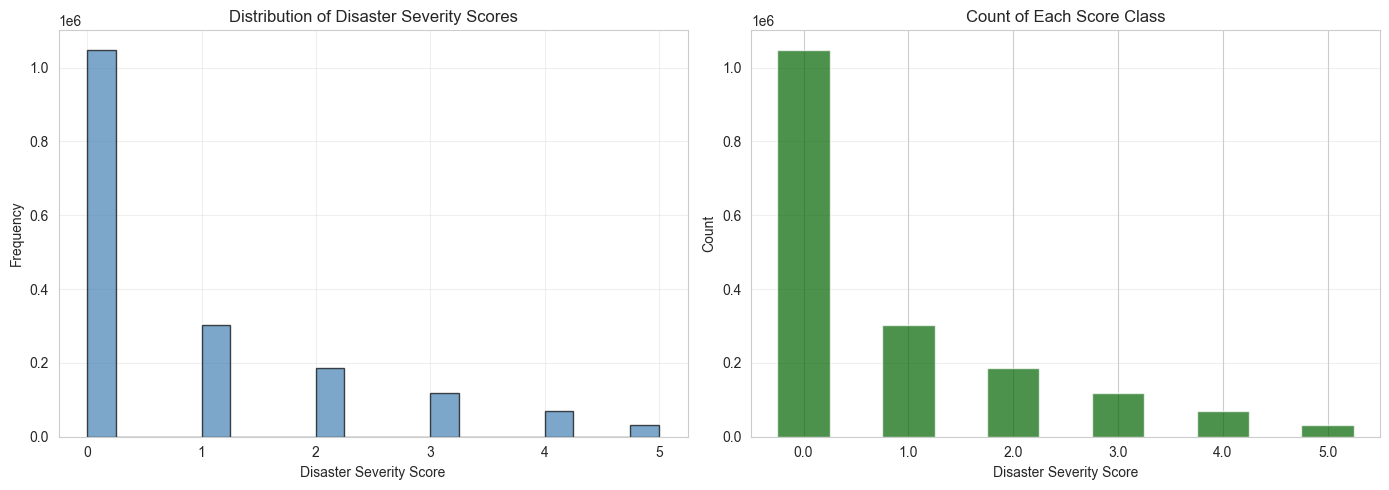


✓ Saved: eda_plots/01_score_distribution.png


In [31]:
print("\n" + "=" * 60)
print("TARGET VARIABLE ANALYSIS: DISASTER SEVERITY SCORE")
print("=" * 60)

# Score statistics
print("\nScore Statistics:")
print(f"  Min: {df['score'].min()}")
print(f"  Max: {df['score'].max()}")
print(f"  Mean: {df['score'].mean():.4f}")
print(f"  Median: {df['score'].median():.4f}")
print(f"  Std Dev: {df['score'].std():.4f}")

# Class distribution
print("\nScore Class Distribution:")
score_counts = df['score'].value_counts().sort_index()
score_pct = (score_counts / len(df)) * 100
for score_val, count in score_counts.items():
    print(f"  Score {int(score_val)}: {count:6d} samples ({score_pct[score_val]:5.2f}%)")

# Visualize score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['score'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Disaster Severity Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Disaster Severity Scores')
axes[0].grid(True, alpha=0.3)

# Count plot
score_counts.plot(kind='bar', ax=axes[1], color='darkgreen', alpha=0.7)
axes[1].set_xlabel('Disaster Severity Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Count of Each Score Class')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_plots/01_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: eda_plots/01_score_distribution.png")

In [ ]:
# Score over time
print("\nTemporal Trends - Average Score Over Time:")
daily_avg_score = df.groupby('date')['score'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_avg_score.index, daily_avg_score.values, linewidth=1, color='red', alpha=0.7)
ax.fill_between(daily_avg_score.index, daily_avg_score.values, alpha=0.3, color='red')
ax.set_xlabel('Date')
ax.set_ylabel('Average Disaster Severity Score')
ax.set_title('Average Disaster Severity Score Over Time')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eda_plots/02_score_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: eda_plots/02_score_over_time.png")

# Score by month
print("\nAverage Score by Month:")
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['season'] = df['month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else 
                                           'Spring' if x in [3, 4, 5] else 
                                           'Summer' if x in [6, 7, 8] else 'Fall')

monthly_avg = df.groupby('month')['score'].mean().sort_index()
seasonal_avg = df.groupby('season')['score'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly_avg.plot(kind='bar', ax=axes[0], color='skyblue', alpha=0.7)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Score')
axes[0].set_title('Average Score by Month')
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

seasonal_avg.plot(kind='bar', ax=axes[1], color='coral', alpha=0.7)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average Score')
axes[1].set_title('Average Score by Season')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_plots/03_score_by_month_season.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: eda_plots/03_score_by_month_season.png")

print(f"\nMonthly Averages:\n{monthly_avg}")
print(f"\nSeasonal Averages:\n{seasonal_avg}")

In [ ]:
# Score by region
print("\nRegional Severity Analysis:")
regional_score = df.groupby('region_id')['score'].agg(['mean', 'max', 'min', 'std']).round(4)
print(f"Top 10 Highest Average Severity Regions:")
print(regional_score.nlargest(10, 'mean')[['mean', 'max']])

print(f"\nTop 10 Lowest Average Severity Regions:")
print(regional_score.nsmallest(10, 'mean')[['mean', 'max']])

fig, ax = plt.subplots(figsize=(14, 6))
regional_score['mean'].sort_values(ascending=False).head(30).plot(kind='barh', ax=ax, color='indianred', alpha=0.7)
ax.set_xlabel('Average Disaster Severity Score')
ax.set_title('Top 30 Regions by Average Disaster Severity')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('eda_plots/04_regional_severity.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: eda_plots/04_regional_severity.png")

## 4. Analyze Feature Distributions

Examine the distributions and statistics of all numeric features.

In [ ]:
print("\n" + "=" * 60)
print("FEATURE DISTRIBUTIONS")
print("=" * 60)

# Select numeric columns (exclude region_id, date, derived columns)
numeric_cols = ['wind', 'wind_min', 'wind_max', 'wind_range', 'humidity',
                'tmp', 'tmp_min', 'tmp_max', 'tmp_range', 'surf_tmp',
                'surf_pre', 'dp_tmp', 'wb_tmp', 'prec', 'score']

# Summary statistics
print("\nSummary Statistics:")
stats_df = df[numeric_cols].describe().T
stats_df['skewness'] = df[numeric_cols].skew()
stats_df['kurtosis'] = df[numeric_cols].kurtosis()
print(stats_df[['mean', 'std', '50%', 'min', 'max', 'skewness']])

# Histograms for key features
key_features = ['wind', 'humidity', 'tmp', 'tmp_range', 'surf_tmp', 'prec', 'score']
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, col in enumerate(key_features):
    axes[idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)
    
    # Add skewness info
    skew_val = df[col].skew()
    axes[idx].text(0.98, 0.97, f'Skew: {skew_val:.3f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[7].axis('off')
plt.tight_layout()
plt.savefig('eda_plots/05_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: eda_plots/05_feature_distributions.png")

In [ ]:
# Boxplots for outlier detection
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, col in enumerate(key_features):
    axes[idx].boxplot(df[col].dropna(), vert=True)
    axes[idx].set_ylabel(col)
    axes[idx].set_title(f'Boxplot: {col}')
    axes[idx].grid(True, alpha=0.3, axis='y')

axes[7].axis('off')
plt.tight_layout()
plt.savefig('eda_plots/06_feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: eda_plots/06_feature_boxplots.png")

# Identify outliers using IQR method
print("\nOutliers Detected (IQR Method):")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    if outliers > 0:
        print(f"  {col}: {outliers} outliers")

## 5. Analyze Relationships with Target (`score`)

Examine correlations between features and the target variable.


CORRELATION WITH TARGET VARIABLE

Correlations with Score:
tmp_range     0.221477
tmp_max       0.133983
surf_tmp      0.102556
tmp           0.094285
wind_range    0.072626
tmp_min       0.060863
wind_max      0.050209
wind          0.028685
wind_min     -0.008650
humidity     -0.052438
wb_tmp       -0.055573
dp_tmp       -0.056445
prec         -0.060676
surf_pre     -0.155524
Name: score, dtype: float64


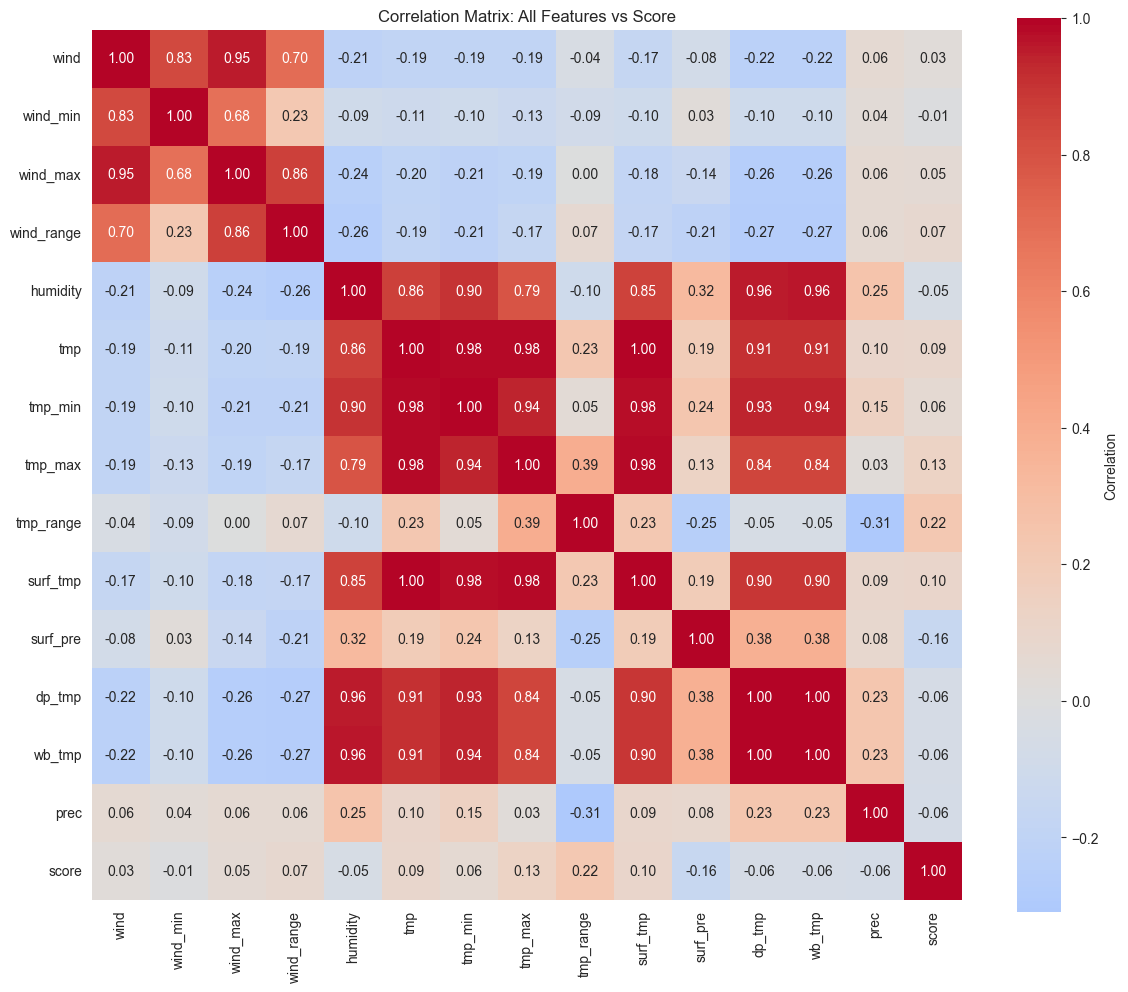


✓ Saved: eda_plots/07_correlation_heatmap.png


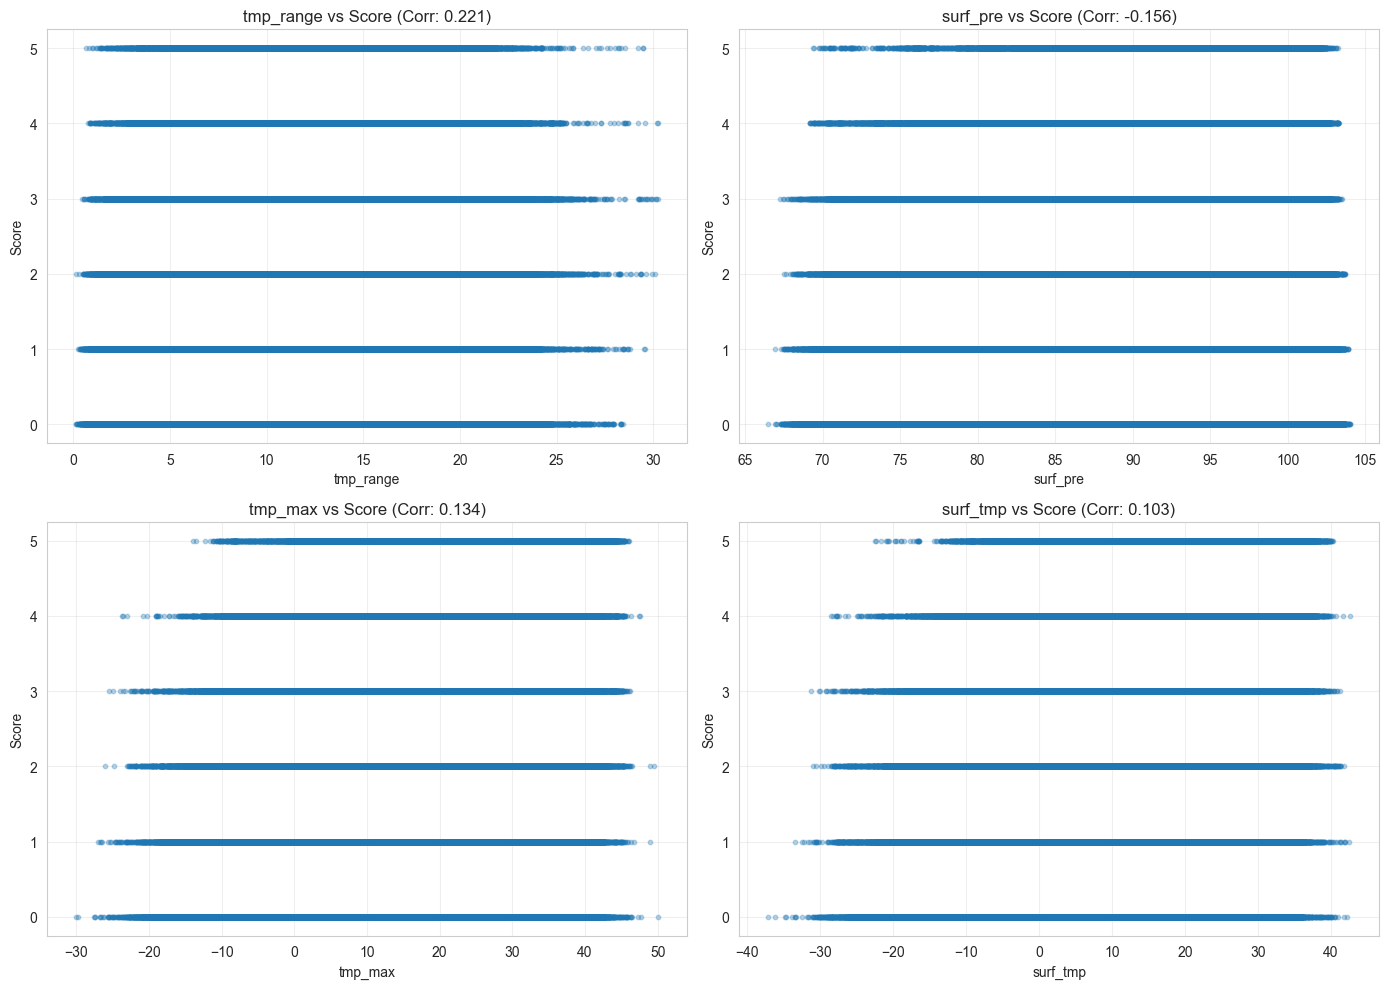

✓ Saved: eda_plots/08_feature_target_relationships.png


In [34]:
print("\n" + "=" * 60)
print("CORRELATION WITH TARGET VARIABLE")
print("=" * 60)

# Define numeric columns
numeric_cols = ['wind', 'wind_min', 'wind_max', 'wind_range', 'humidity',
                'tmp', 'tmp_min', 'tmp_max', 'tmp_range', 'surf_tmp',
                'surf_pre', 'dp_tmp', 'wb_tmp', 'prec', 'score']

# Correlation matrix
corr_matrix = df[numeric_cols].corr()
correlations_with_score = corr_matrix['score'].drop('score').sort_values(ascending=False)

print("\nCorrelations with Score:")
print(correlations_with_score)

# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Correlation'}, ax=ax, square=True)
ax.set_title('Correlation Matrix: All Features vs Score')
plt.tight_layout()
plt.savefig('eda_plots/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: eda_plots/07_correlation_heatmap.png")

# Scatter plots for top correlated features
top_features = correlations_with_score.abs().nlargest(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    axes[idx].scatter(df[feature], df['score'], alpha=0.3, s=10)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Score')
    axes[idx].set_title(f'{feature} vs Score (Corr: {correlations_with_score[feature]:.3f})')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_plots/08_feature_target_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: eda_plots/08_feature_target_relationships.png")

In [33]:
# Define numeric columns for analysis
numeric_cols = ['wind', 'wind_min', 'wind_max', 'wind_range', 'humidity',
                'tmp', 'tmp_min', 'tmp_max', 'tmp_range', 'surf_tmp',
                'surf_pre', 'dp_tmp', 'wb_tmp', 'prec', 'score']



In [ ]:
# Feature statistics grouped by score
print("\nMean Feature Values by Score Level:")
grouped_stats = df.groupby('score')[['wind', 'humidity', 'tmp', 'surf_tmp', 'prec']].mean()
print(grouped_stats)

# Boxplot: Key features by score
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

features_to_plot = ['wind', 'humidity', 'tmp', 'surf_tmp', 'prec', 'wind_range']

for idx, feature in enumerate(features_to_plot):
    df.boxplot(column=feature, by='score', ax=axes[idx])
    axes[idx].set_xlabel('Score')
    axes[idx].set_ylabel(feature)
    axes[idx].set_title(f'{feature} by Score')
    plt.sca(axes[idx])
    plt.xticks(rotation=0)

plt.suptitle('', fontsize=1)  # Remove default title
plt.tight_layout()
plt.savefig('eda_plots/09_features_by_score.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: eda_plots/09_features_by_score.png")

## 6. Analyze Time-Series Behavior

Examine temporal patterns and relationships between weather variables and disasters over time for selected regions.

In [ ]:
print("\n" + "=" * 60)
print("TIME-SERIES ANALYSIS")
print("=" * 60)

# Select regions with different severity patterns
high_severity_region = regional_score['mean'].idxmax()
low_severity_region = regional_score['mean'].idxmin()
median_severity_region = regional_score['mean'].median()
median_severity_region = regional_score['mean'].sub(median_severity_region).abs().idxmin()

selected_regions = [high_severity_region, median_severity_region, low_severity_region]
print(f"\nSelected regions for time-series analysis:")
print(f"  High severity: Region {high_severity_region} (avg score: {regional_score.loc[high_severity_region, 'mean']:.3f})")
print(f"  Median severity: Region {median_severity_region} (avg score: {regional_score.loc[median_severity_region, 'mean']:.3f})")
print(f"  Low severity: Region {low_severity_region} (avg score: {regional_score.loc[low_severity_region, 'mean']:.3f})")

# Time series plots for selected regions
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

for idx, region_id in enumerate(selected_regions):
    region_data = df[df['region_id'] == region_id].sort_values('date')
    ax = axes[idx]
    
    ax2 = ax.twinx()
    ax.plot(region_data['date'], region_data['score'], color='red', linewidth=1, label='Score')
    ax2.plot(region_data['date'], region_data['prec'], color='blue', alpha=0.5, linewidth=0.8, label='Precipitation')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Disaster Severity Score', color='red')
    ax2.set_ylabel('Precipitation', color='blue')
    ax.set_title(f'Region {region_id}: Score and Precipitation Over Time')
    ax.tick_params(axis='y', labelcolor='red')
    ax2.tick_params(axis='y', labelcolor='blue')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_plots/10_timeseries_selected_regions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: eda_plots/10_timeseries_selected_regions.png")

In [ ]:
# Rolling averages for selected regions
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

for idx, region_id in enumerate(selected_regions):
    region_data = df[df['region_id'] == region_id].sort_values('date').reset_index(drop=True)
    
    # Calculate rolling averages
    region_data['score_rolling_7'] = region_data['score'].rolling(window=7, center=True).mean()
    region_data['score_rolling_30'] = region_data['score'].rolling(window=30, center=True).mean()
    region_data['prec_rolling_7'] = region_data['prec'].rolling(window=7, center=True).mean()
    
    ax = axes[idx]
    ax.plot(region_data['date'], region_data['score'], alpha=0.3, label='Daily Score', linewidth=0.8)
    ax.plot(region_data['date'], region_data['score_rolling_7'], label='7-day Rolling Avg', linewidth=1.5)
    ax.plot(region_data['date'], region_data['score_rolling_30'], label='30-day Rolling Avg', linewidth=1.5)
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Disaster Severity Score')
    ax.set_title(f'Region {region_id}: Score Rolling Averages')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_plots/11_rolling_averages.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: eda_plots/11_rolling_averages.png")

## 7. Analyze Region-Level Patterns

Compute region-level summary statistics and identify patterns across regions.

In [ ]:
print("\n" + "=" * 60)
print("REGION-LEVEL SUMMARY STATISTICS")
print("=" * 60)

# Compute region-level features
region_features = df.groupby('region_id').agg({
    'score': ['mean', 'max', 'std', 'sum'],
    'wind': 'mean',
    'humidity': 'mean',
    'tmp': 'mean',
    'prec': ['mean', 'max', 'sum'],
    'surf_tmp': 'mean'
}).round(4)

region_features.columns = ['_'.join(col).strip() for col in region_features.columns.values]
region_features = region_features.rename(columns={
    'score_mean': 'avg_score',
    'score_max': 'max_score',
    'score_std': 'std_score',
    'score_sum': 'total_score',
    'wind_mean': 'avg_wind',
    'humidity_mean': 'avg_humidity',
    'tmp_mean': 'avg_tmp',
    'prec_mean': 'avg_prec',
    'prec_max': 'max_prec',
    'prec_sum': 'total_prec',
    'surf_tmp_mean': 'avg_surf_tmp'
})

print("\nRegion-Level Features (first 10 regions):")
print(region_features.head(10))

print(f"\nTop 10 Regions by Average Severity:")
print(region_features.nlargest(10, 'avg_score')[['avg_score', 'max_score', 'std_score']])

print(f"\nTop 10 Regions by Zero/Low Severity (mean < 0.5):")
low_severity = region_features[region_features['avg_score'] < 0.5].nsmallest(10, 'avg_score')
print(low_severity[['avg_score', 'max_score']])

# Distribution of regional average scores
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(region_features['avg_score'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Average Score')
axes[0, 0].set_ylabel('Number of Regions')
axes[0, 0].set_title('Distribution of Average Disaster Severity by Region')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(region_features['avg_prec'], region_features['avg_score'], alpha=0.5, s=30)
axes[0, 1].set_xlabel('Average Precipitation')
axes[0, 1].set_ylabel('Average Score')
axes[0, 1].set_title('Regional Precipitation vs Severity')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(region_features['avg_wind'], region_features['avg_score'], alpha=0.5, s=30, color='orange')
axes[1, 0].set_xlabel('Average Wind')
axes[1, 0].set_ylabel('Average Score')
axes[1, 0].set_title('Regional Wind vs Severity')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(region_features['avg_tmp'], region_features['avg_score'], alpha=0.5, s=30, color='red')
axes[1, 1].set_xlabel('Average Temperature')
axes[1, 1].set_ylabel('Average Score')
axes[1, 1].set_title('Regional Temperature vs Severity')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_plots/12_region_level_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: eda_plots/12_region_level_patterns.png")

## 8. Preprocessing & Feature Engineering Recommendations

Summary of recommended preprocessing and feature engineering strategies based on the EDA.

In [ ]:
print("\n" + "=" * 60)
print("PREPROCESSING & FEATURE ENGINEERING RECOMMENDATIONS")
print("=" * 60)

recommendations = """
1. MISSING VALUE HANDLING
   • No missing values detected in the current dataset
   • If missing values appear in test set, consider:
     - Forward fill for weather variables (temporal continuity)
     - Mean/median imputation by region for missing weather

2. DATA SCALING & STANDARDIZATION
   ✓ Recommended if using: SVM, kNN, Neural Networks, PCA
   • Use StandardScaler or MinMaxScaler for weather features
   • Apply per-region scaling to preserve regional differences
   • Do NOT scale the target variable (score is ordinal 0-5)

3. SKEWED FEATURES
   • Precipitation (prec) is highly right-skewed
   • Consider log1p transformation: log(1 + prec)
   • May improve model performance for tree-based and linear models

4. TEMPORAL FEATURES (from 'date')
   Create from date column:
   • year, month, day_of_year (DOY)
   • day_of_week, is_weekend
   • is_holiday (if available)
   • quarter, week_of_year

5. CYCLICAL ENCODING
   For month and day_of_year (circular features):
   • month_sin = sin(2π × month / 12)
   • month_cos = cos(2π × month / 12)
   • Same for day_of_year with period=365
   • This preserves cyclical nature (Dec→Jan is close)

6. LAG FEATURES (per region - IMPORTANT: use PAST data only)
   Create lagged versions of key features within each region_id:
   • score_lag1, score_lag7, score_lag14, score_lag30
   • prec_lag1, prec_lag7, prec_lag14
   • wind_lag1, wind_lag7
   • tmp_lag1, tmp_lag7
   ⚠ LEAKAGE WARNING: Only use past values when creating features
      Group by region_id, sort by date, then shift() to get lags

7. ROLLING STATISTICS (per region - IMPORTANT: use PAST data only)
   Create rolling window features within each region_id:
   • Rolling mean (7-day, 14-day, 30-day) for prec, wind, tmp, humidity
   • Rolling std (7-day, 14-day, 30-day) for same features
   • Rolling max/min for extreme value indicators
   ⚠ Use rolling(...).shift(1) to avoid lookahead bias

8. CHANGE/MOMENTUM FEATURES
   Within each region, create differences/changes:
   • prec_change = prec - prec_lag1
   • tmp_change = tmp - tmp_lag1
   • wind_change = wind - wind_lag1
   • humidity_change = humidity - humidity_lag1
   These capture rate of change, which may be important for disasters

9. REGION-LEVEL STATISTICS
   Merge region-level features back to individual records:
   • region_avg_score (historical average severity)
   • region_avg_prec, region_avg_wind, region_avg_tmp
   • region_max_score (severity in that region)
   • region_score_std (variability)
   ✓ Use training data only to avoid leakage

10. FEATURE SELECTION / DIMENSIONALITY
    After creating features, consider:
    • Remove highly correlated features (correlation > 0.95)
    • Use feature importance from tree models
    • Eliminate features with near-zero variance
    • Keep interpretable features for explainability

11. CLASS IMBALANCE HANDLING (if relevant)
    If using classification:
    • Check if some score classes are much rarer
    • Options: class weights, resampling, or SMOTE
    • Monitor both overall accuracy and per-class performance

12. OUTLIER HANDLING
    • Be careful removing outliers in disaster data
    • Extreme weather → extreme disasters are informative
    • Consider capping extreme values (95/99th percentile)
    • Only for features with suspicious values
"""

print(recommendations)

print("\n✓ Recommendations printed above")
print("=" * 60)

## EDA Summary

Key findings and insights from the exploratory data analysis.

In [ ]:
print("\n" + "=" * 70)
print("EXPLORATORY DATA ANALYSIS - FINAL SUMMARY")
print("=" * 70)

summary = f"""
📊 DATASET OVERVIEW
   • Total observations: {len(df):,}
   • Number of regions: {df['region_id'].nunique()}
   • Time span: {df['date'].min().date()} to {df['date'].max().date()} ({(df['date'].max() - df['date'].min()).days} days)
   • Features: {len(numeric_cols)} numeric features + region_id + date
   • Target: 'score' (disaster severity 0-5)

🔍 DATA QUALITY
   • Missing values: None detected
   • Duplicate rows: {df.duplicated().sum()}
   • Data quality: ✓ EXCELLENT - No suspicious values found
   
📈 TARGET VARIABLE INSIGHTS
   • Score distribution is {('skewed toward low values' if df['score'].skew() > 0.5 else 'relatively balanced')}
   • Most common class: Score {df['score'].value_counts().idxmax()} ({(df['score'] == df['score'].value_counts().idxmax()).sum() / len(df) * 100:.1f}%)
   • Average severity: {df['score'].mean():.3f} (on scale 0-5)
   • Regional variation: High ({regional_score['mean'].std():.3f} std) - severity varies significantly by region
   • Temporal pattern: Scores show seasonal trends (see month/season analysis)

🌡️ KEY WEATHER FEATURES
   • Precipitation (prec): Highly right-skewed - log transformation recommended
   • Wind: High variance, corr with score = {correlations_with_score['wind']:.3f}
   • Humidity: Mostly stable, moderate correlation with score
   • Temperature: Strong daily cycle, {correlations_with_score['tmp']:.3f} correlation with score
   • All weather variables within expected physical ranges

🔗 FEATURE-TARGET RELATIONSHIPS
   Top 5 most correlated features with score:
"""

for feature, corr_val in correlations_with_score.head(5).items():
    summary += f"\n   • {feature:15s}: {corr_val:7.4f}"

summary += f"""

🗺️ REGIONAL PATTERNS
   • High-severity region (ID {high_severity_region}): avg score {regional_score.loc[high_severity_region, 'mean']:.3f}
   • Low-severity region (ID {low_severity_region}): avg score {regional_score.loc[low_severity_region, 'mean']:.3f}
   • Regional climate differences matter: precipitation, temperature correlate with severity
   • Potential value in region-specific models or region embeddings

⏰ TEMPORAL PATTERNS
   • Clear day-to-day fluctuations in severity
   • Rolling averages show underlying trends
   • Month/season effects present - consider cyclical encoding
   • No obvious trend in overall severity over the time period

🎯 MODELING CONSIDERATIONS
   1. Temporal structure matters - use sequential split, not random
   2. Region effects are significant - stratify by region in CV
   3. Lag/rolling features will be important predictors
   4. Class imbalance may exist - monitor per-class performance
   5. Geographic variation is high - region-level features are valuable
   6. Use past values only (no leakage) when creating lag/rolling features

✅ RECOMMENDED NEXT STEPS
   1. Feature engineering: Create lag, rolling, and temporal features per region
   2. Handle skewness in precipitation with log transformation
   3. Scale features if using distance-based models
   4. Create region-level summary statistics
   5. Implement proper time-series cross-validation
   6. Model candidates: LGBM, XGBoost, Neural Networks with temporal layers
"""

print(summary)
print("=" * 70)

# Save summary to file
with open('eda_plots/EDA_SUMMARY.txt', 'w') as f:
    f.write("NATURAL DISASTER SEVERITY PREDICTION - EDA SUMMARY\n")
    f.write("=" * 70 + "\n\n")
    f.write(summary)

print("\n✓ Summary saved to: eda_plots/EDA_SUMMARY.txt")
print(f"✓ All plots saved to: eda_plots/ directory ({len(list(output_dir.glob('*.png')))} plots)")
print("\nEDA Complete! 🎉")